# Observability, duality and the construction of controls

*Introduction to Control and Machine Learning · Part I: Control · Notebook 03*

> **Central question.** *How can the problem of finding a control be transformed into an optimization problem for an adjoint system?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 60–75 min · DEEPER LOOK sections ≈ 20 min more |
| **Execution time** | a few seconds for the whole notebook |
| **Exercises** | 6 exercises, ≈ 60–120 min depending on the selection |
| **Prerequisites** | [Notebook 02](02_linear_control_kalman.ipynb) (recapped below, so this notebook can be read on its own); linear algebra; minimizing a quadratic form |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 20, 87–100, 105–106, 111 (see the Source map at the end) |
| **Notation** | `notation.md` §1; the two observability constants $c_0$ and $c_{\rm term}$ are introduced in §5 |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks; they can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

**The chain this notebook builds**, one justified step at a time:
controllability → duality → adjoint system → observability → coercivity → minimization → control.

**Learning objectives.** After completing this notebook you should be able to

1. derive the duality identity between the state equation and its adjoint, and use it to characterize controllability;
2. explain why the adjoint system appears naturally, not as a trick;
3. reverse-engineer the HUM functional $J(\varphi_T)$ from the condition a control must satisfy;
4. prove the chain unique continuation ⇒ observability ⇒ coercivity ⇒ existence and uniqueness of the minimizer, and say exactly where finite dimension is used;
5. construct the control $u=B^*\hat{\varphi}$ and prove that it has minimal $L^2$ norm;
6. relate the Gramian's eigenvalues to the cost of control in hard directions, and its condition number to the speed of gradient descent.

## Where are we?
`CORE`

> **Recap of [notebook 02](02_linear_control_kalman.ipynb).** We control the linear system
> $$x'(t)=Ax(t)+Bu(t),\quad t\in(0,T),\qquad x(0)=x^0,$$
> with $A\in\mathbb R^{n\times n}$, $B\in\mathbb R^{n\times m}$ and $u\in L^2(0,T;\mathbb R^m)$.
> - **Variation of constants:** $x(t)=e^{At}x^0+\int_0^t e^{A(t-s)}Bu(s)\,ds$ (PDF p. 88).
> - **Controllability:** the system is *exactly controllable in time $T$* if for all $x^0,x^1\in\mathbb R^n$ there is a control with $x(T)=x^1$. Equivalently, the reachable set $\mathcal{R}(T,x^0)=e^{AT}x^0+\operatorname{Range}\mathcal{K}(A,B)$ is all of $\mathbb R^n$ (pp. 88, 91).
> - **Kalman rank condition:** controllable ⟺ $\operatorname{rank}\mathcal{K}(A,B)=\operatorname{rank}[B,AB,\dots,A^{n-1}B]=n$, and then controllable for *every* $T>0$ (p. 99).
> - **Controllability Gramian:** $\mathcal{G}_T=\int_0^Te^{A(T-s)}BB^*e^{A^*(T-s)}\,ds$, symmetric, positive semidefinite, and invertible exactly when Kalman's condition holds. One control that steers $x^0$ to $x^1$ is
> $$u(t)=B^*e^{A^*(T-t)}\,\mathcal{G}_T^{-1}\big(x^1-e^{AT}x^0\big).\tag{G}$$

Notebook 02 *verified* that formula (G) works. It did not explain where it comes from, why it has this particular form, or what is special about it among the infinitely many controls that reach $x^1$.

This notebook answers those questions by changing the point of view. Instead of searching for $u$ directly, we will **test** the final state against every direction and see what this tells us about $u$. That leads to an adjoint system, to an optimization problem for that adjoint system, and, in the end, back to formula (G), now with a reason behind it.

*Convention.* The slides (pp. 92–95) treat **null controllability**, $x^1=0$. We treat a general target $x^1$, as the slides do later (p. 111), because it costs nothing extra. For linear finite-dimensional systems the two notions are equivalent: steering $x^0$ to $x^1$ is the same as steering $x^0-e^{-AT}x^1$ to $0$.

## 1. Why introduce an adjoint?
`CORE`

The requirement $x(T)=x^1$ is an equation between vectors in $\mathbb R^n$. A vector is determined by its components in every direction, so the requirement is equivalent to the family of **scalar** conditions

$$
\langle x(T),\eta\rangle=\langle x^1,\eta\rangle\qquad\text{for every test direction }\eta\in\mathbb R^n .
$$

Let us see how the control enters one such scalar condition. Insert the variation-of-constants formula and move each matrix to the other side of the inner product, using $\langle Mv,w\rangle=\langle v,M^*w\rangle$:

$$
\begin{aligned}
\langle x(T),\eta\rangle
&=\big\langle e^{AT}x^0,\eta\big\rangle+\int_0^T\big\langle e^{A(T-s)}Bu(s),\eta\big\rangle\,ds\\
&=\big\langle x^0,\,e^{A^*T}\eta\big\rangle+\int_0^T\big\langle u(s),\,B^*e^{A^*(T-s)}\eta\big\rangle\,ds .
\end{aligned}
$$

A new object has appeared on its own: the function

$$
\varphi(s)=e^{A^*(T-s)}\eta .
$$

It is the solution of a linear ODE that runs **backward** from the final time, $-\varphi'=A^*\varphi$ with $\varphi(T)=\eta$. This is the *adjoint system*. Three observations explain why it deserves a name.

1. **Vector conditions become scalar identities.** For each test direction $\eta$, the condition $\langle x(T),\eta\rangle=\langle x^1,\eta\rangle$ is one linear equation for $u$, and $u$ enters it only through $\int_0^T\langle u,B^*\varphi\rangle$.
2. **The control sees the test direction only through $B^*\varphi$.** If $B^*\varphi\equiv0$ for some $\eta\ne0$, no control can change $\langle x(T),\eta\rangle$, and that direction is out of reach. Controllability will therefore have to do with whether $B^*\varphi$ can vanish identically.
3. **$B^*\varphi(s)$ is a sensitivity.** Perturbing the control by $\delta u$ changes the scalar output $\langle x(T),\eta\rangle$ by $\int_0^T\langle\delta u(s),B^*\varphi(s)\rangle\,ds$. So $B^*\varphi(s)$ is the gradient of that output with respect to $u(s)$. The adjoint carries information *from the final time back to every earlier time*.

So the adjoint is not an arbitrary device. It is what we get when we ask *how the final state, measured in a direction $\eta$, depends on the control*.

## 2. The adjoint system
`CORE`

**Definition (adjoint system, p. 92).** For a terminal datum $\varphi_T\in\mathbb R^n$, the adjoint system of $x'=Ax+Bu$ is

$$
-\varphi'(t)=A^*\varphi(t),\quad t\in(0,T),\qquad \varphi(T)=\varphi_T,
\tag{ADJ}
$$

with solution $\varphi(t)=e^{A^*(T-t)}\varphi_T$. The quantity $B^*\varphi(t)\in\mathbb R^m$ is called the **observation** of the adjoint state.

Compared with the state equation, three things change. The adjoint is posed **backward**, with data at $t=T$. It involves $A^*$ instead of $A$. And it has **no control**: it is a homogeneous equation. The map $\varphi_T\mapsto\varphi(0)=e^{A^*T}\varphi_T$ is an invertible linear map of $\mathbb R^n$ with a *bounded* inverse. We will use this later; in infinite dimension that bounded inverse can be lost (§11).

**Running example E1, the harmonic oscillator.** For $x_1''+x_1=u$, written as a first-order system with $A=\begin{pmatrix}0&1\\-1&0\end{pmatrix}$ and $B=\begin{pmatrix}0\\1\end{pmatrix}$, we have $A^*=-A$, and the observation is the second component, $B^*\varphi=\varphi_2$.

> **Predict.** Before running the next cells: what does the observation $B^*\varphi(t)=\varphi_2(t)$ look like as a function of $t$ for E1? Is $|\varphi(t)|$ constant?

The first code cell loads the shared code of the course (`src/control_utils.py`, where each function implements one formula of this notebook). The notebook must be run from inside the complete `CML_notebooks` repository; see `README.md`, *Installation*.

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from scipy.linalg import expm
from scipy.optimize import minimize

from src.control_utils import (harmonic_oscillator, near_uncontrollable_system, kalman_matrix,
                               kalman_rank, gramian, observability_constant, adjoint_trajectory,
                               hum_functional, hum_minimizer, hum_control, gramian_control,
                               simulate, sample, time_grid, l2_norm)
from src.plotting_utils import apply_style, slope_guide, COLORS

apply_style()
rng = np.random.default_rng(seed=3)        # the only source of randomness in this notebook
np.set_printoptions(precision=5, suppress=True)

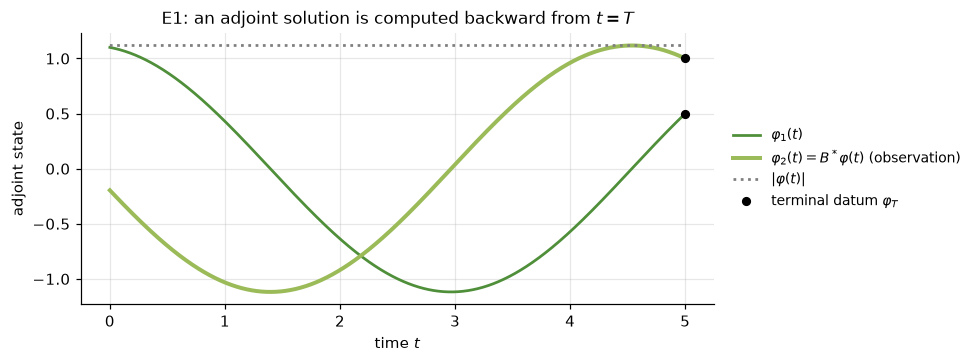

In [2]:
A, B = harmonic_oscillator()          # E1:  x1'' + x1 = u
T = 5.0                               # control horizon (less than one period 2*pi)
t = time_grid(T, 2000)

phi_T_example = np.array([0.5, 1.0])              # an arbitrary terminal datum
phi_example = adjoint_trajectory(A, phi_T_example, t, T)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(t, phi_example[:, 0], color=COLORS["adjoint"], label=r"$\varphi_1(t)$")
ax.plot(t, phi_example[:, 1], color=COLORS["adjoint2"], lw=2.6, label=r"$\varphi_2(t)=B^*\varphi(t)$ (observation)")
ax.plot(t, np.linalg.norm(phi_example, axis=1), ":", color=COLORS["reference"], label=r"$|\varphi(t)|$")
ax.plot([T, T], phi_T_example, "o", color="black", ms=5, label=r"terminal datum $\varphi_T$")
ax.set_xlabel("time $t$"); ax.set_ylabel("adjoint state")
ax.set_title("E1: an adjoint solution is computed backward from $t=T$")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5)); plt.tight_layout(); plt.show()

**Figure 1.** The adjoint solution $\varphi(t)=e^{A^*(T-t)}\varphi_T$ of E1 for $\varphi_T=(0.5,1)$ and $T=5$. The black dots mark the terminal datum, from which the solution is computed backward.

*Interpretation (answer to the prediction).* Since $A^*=-A$ is skew-symmetric, the adjoint rotates at the oscillator's natural frequency, and $|\varphi(t)|$ is constant. The observation $B^*\varphi$ is therefore a sinusoid, $B^*\varphi(t)=\varphi_{T,1}\sin(T-t)+\varphi_{T,2}\cos(T-t)$. Every control produced in this notebook will be such a curve.

## 3. The fundamental duality identity
`CORE`

We now derive the same identity *without* the explicit formula $e^{At}$, using only the two differential equations. This second derivation matters because it carries over to time-dependent coefficients and to PDEs, where there is no matrix exponential but integration by parts still works ([notebook 07](07_adjoints_density_heat_control.ipynb)).

**Step 1. Differentiate the pairing.** Let $x$ solve the state equation with control $u$, and let $\varphi$ solve (ADJ). By the product rule,
$$
\frac{d}{dt}\langle x(t),\varphi(t)\rangle=\langle x',\varphi\rangle+\langle x,\varphi'\rangle .
$$

**Step 2. Insert the equations.** Using $x'=Ax+Bu$ and $\varphi'=-A^*\varphi$,
$$
\frac{d}{dt}\langle x,\varphi\rangle=\langle Ax,\varphi\rangle+\langle Bu,\varphi\rangle-\langle x,A^*\varphi\rangle=\langle Bu,\varphi\rangle=\langle u,B^*\varphi\rangle .
$$
The terms with $A$ cancel exactly: **the adjoint is built so that they do**. Only the control term survives.

**Step 3. Integrate over $(0,T)$.** For every $\varphi_T\in\mathbb R^n$,

$$
\boxed{\;\langle x(T),\varphi_T\rangle-\langle x^0,\varphi(0)\rangle=\int_0^T\langle u(t),B^*\varphi(t)\rangle\,dt .\;}
\tag{D}
$$

Identity (D) is a **conservation law with a source**. Without control, the pairing $\langle x(t),\varphi(t)\rangle$ is constant in time. The control changes it at the rate $\langle u,B^*\varphi\rangle$.

> **Lemma 1 (controllability as a family of identities; p. 92, general target as on p. 111).**
> *Assumption:* $u\in L^2(0,T;\mathbb R^m)$.
> *Conclusion:* $u$ steers $x^0$ to $x^1$ if and only if, for every $\varphi_T\in\mathbb R^n$,
> $$\int_0^T\langle u,B^*\varphi\rangle\,dt=\langle x^1,\varphi_T\rangle-\langle x^0,\varphi(0)\rangle .\tag{C}$$
> *Interpretation:* a control is a solution of $n$ linear equations, one for each basis direction $\varphi_T=e_j$. The unknown $u$ lives in an infinite-dimensional space.

*Proof.* By (D), condition (C) is equivalent to $\langle x(T)-x^1,\varphi_T\rangle=0$ for every $\varphi_T$. Taking $\varphi_T=x(T)-x^1$ gives $|x(T)-x^1|^2=0$. The converse is immediate. $\square$

> **Remark on the source slides.** The slides write the terminal datum of the adjoint as $\varphi_T$ on pp. 92–96 but as $\varphi^0$ on p. 111, with $J(\varphi^0)$. Both denote $\varphi(T)$. We always write $\varphi_T$, because $\varphi^0$ suggests a value at $t=0$.

The next cell checks (D) numerically for E1, with an arbitrary control and an arbitrary test direction. Both sides are computed independently: the left side by simulating the state, the right side by quadrature along the adjoint.

In [3]:
x0 = np.array([1.0, 0.0])                         # start: displaced, at rest
u_test = lambda s: np.array([np.sin(3 * s)])      # any control will do
phi_T_test = np.array([1.0, 2.0])                 # any test direction will do

x_end = simulate(A, B, u_test, x0, T, [0.0, T])[-1]
phi_test = adjoint_trajectory(A, phi_T_test, t, T)
lhs = x_end @ phi_T_test - x0 @ phi_test[0]
rhs = simpson(np.sum(sample(u_test, t) * (phi_test @ B), axis=1), x=t)
print(f"<x(T), phi_T> - <x0, phi(0)>  = {lhs:.10f}")
print(f"int_0^T <u, B* phi> dt        = {rhs:.10f}")

<x(T), phi_T> - <x0, phi(0)>  = 0.3416299907
int_0^T <u, B* phi> dt        = 0.3416299907


## 4. From the identity to a functional
`CORE`

Condition (C) tells us *which* controls work, but not how to find one. The aim of this section is to turn (C) into a minimization problem. We do not pull a functional out of a hat: we **reverse-engineer** it from the equation we want its minimizer to satisfy.

**Step 1. Look at (C) geometrically.** In the Hilbert space $L^2(0,T;\mathbb R^m)$ with inner product $(u,v)=\int_0^T\langle u,v\rangle\,dt$, the left side of (C) is $(u,B^*\varphi)$. Consider the set of functions
$$
V=\{\,t\mapsto B^*\varphi(t)\;:\;\varphi_T\in\mathbb R^n\,\}\subset L^2(0,T;\mathbb R^m),
$$
a subspace of dimension at most $n$. Condition (C) prescribes the inner products of $u$ with the elements of $V$, and with nothing else. Any component of $u$ orthogonal to $V$ is invisible to the constraints: it costs effort and achieves nothing. The most economical candidate is therefore a control lying in $V$ itself:

$$
u=B^*\hat{\varphi}\quad\text{for some adjoint solution }\hat{\varphi}\text{ with terminal datum }\hat{\varphi}_T .
\tag{ansatz}
$$

(§7 proves that this candidate is the control of minimal norm.)

**Step 2. Insert the ansatz into (C).** We need $\hat{\varphi}_T$ such that, for every $\varphi_T$,

$$
\int_0^T\langle B^*\hat{\varphi},B^*\varphi\rangle\,dt=\langle x^1,\varphi_T\rangle-\langle x^0,\varphi(0)\rangle .
\tag{EL}
$$

The unknown is now a vector $\hat{\varphi}_T\in\mathbb R^n$, not a function.

**Step 3. Recognize (EL) as an optimality condition.** The left side, $a(\hat{\varphi}_T,\varphi_T):=\int_0^T\langle B^*\hat{\varphi},B^*\varphi\rangle\,dt$, is a *symmetric bilinear* form. The right side, $\ell(\varphi_T):=\langle x^1,\varphi_T\rangle-\langle x^0,\varphi(0)\rangle$, is *linear*. For any symmetric bilinear $a$ and linear $\ell$, the directional derivative of $\tfrac12a(\phi,\phi)-\ell(\phi)$ at $\hat{\varphi}_T$ in a direction $\varphi_T$ is $a(\hat{\varphi}_T,\varphi_T)-\ell(\varphi_T)$. So (EL) says exactly that *all directional derivatives of the following functional vanish at $\hat{\varphi}_T$*:

$$
\boxed{\;J(\varphi_T)=\frac12\int_0^T|B^*\varphi(t)|^2\,dt-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle,\qquad\varphi\text{ the solution of (ADJ)}.\;}
\tag{HUM}
$$

(EL) is the Euler–Lagrange equation of $J$. We did not start from $J$: we *constructed* it so that its critical points produce controls. In the literature this is the **Hilbert Uniqueness Method (HUM)** of J.-L. Lions; the slides use the functional without the name. For $x^1=0$ it is exactly the functional of p. 94.

> **Lemma 2 (minimizers give controls; p. 94).**
> *Assumption:* $J$ has a minimizer $\hat{\varphi}_T$.
> *Conclusion:* $u=B^*\hat{\varphi}$, where $\hat{\varphi}$ solves (ADJ) with datum $\hat{\varphi}_T$, steers $x^0$ to $x^1$.

*Proof.* At a minimizer of a differentiable function, all directional derivatives vanish, so (EL) holds. (EL) is (C) for $u=B^*\hat{\varphi}$, and Lemma 1 concludes. $\square$

The whole difficulty has moved to one question: **does $J$ have a minimizer, and is it unique?** The next section answers it, and the answer is observability.

## 5. Observability and coercivity
`CORE`

A function $J:\mathbb R^n\to\mathbb R$ is **coercive** if $J(z)\to+\infty$ as $|z|\to\infty$, that is, if for every $R$ there is $\rho$ such that $J(z)\ge R$ whenever $|z|\ge\rho$. (Growth along each fixed ray is *not* enough.) The linear terms of $J$ grow at most like $|\varphi_T|$, so coercivity must come from the quadratic term $\int_0^T|B^*\varphi|^2$. The argument has four links:

$$
\begin{aligned}
&\text{unique continuation}\;\Longrightarrow\;\text{observability}\;\Longrightarrow\;\text{coercivity of }J,\\
&\text{continuity}+\text{coercivity}\;\Longrightarrow\;\text{existence of a minimizer},\\
&\text{strict convexity}\;\Longrightarrow\;\text{uniqueness}.
\end{aligned}
$$

**(a) Unique continuation.** If the observation $B^*\varphi$ vanishes on all of $(0,T)$, then $\varphi_T=0$. In words: *the observation determines the adjoint state*.

In finite dimension this is exactly Kalman's condition (p. 100). Differentiating $B^*e^{A^*(T-t)}\varphi_T\equiv0$ repeatedly at $t=T$ gives $B^*(A^*)^k\varphi_T=0$ for all $k$, that is, $\varphi_T\perp\operatorname{Range}[B,AB,\dots,A^{n-1}B]$. Conversely, such $\varphi_T$ make $B^*\varphi\equiv0$, by the power series of the exponential and Cayley–Hamilton. Hence unique continuation ⟺ $\operatorname{rank}\mathcal{K}(A,B)=n$.

**(b) Observability.** The adjoint system is **observable in time $T$** if there is $c_0>0$ such that

$$
\int_0^T|B^*\varphi(t)|^2\,dt\;\ge\;c_0\,|\varphi(0)|^2\qquad\text{for every solution of (ADJ)}.
\tag{OBS}
$$

This is the *quantitative* version of unique continuation, in the form used on the slides (p. 96): a *small* observation forces a *small* state. We write $c_0(T)$, or just $c_0$, for the best constant. It is the slides' $c$, and the subscript recalls that the state is measured at $t=0$.

Measuring the state at the terminal time instead gives the **terminal form** $\int_0^T|B^*\varphi|^2\ge c_{\rm term}|\varphi_T|^2$. In finite dimension the two forms are equivalent, because $\varphi_T\mapsto\varphi(0)$ has a bounded inverse. With $M=\|e^{-A^*T}\|$ we have $|\varphi_T|\le M|\varphi(0)|$, hence $c_{\rm term}\ge c_0/M^2$, and similarly $c_0\ge c_{\rm term}/\|e^{A^*T}\|^2$.

> **Proposition 3 (p. 97).** In finite dimension, unique continuation ⟺ observability.

*Proof.* "⇐": if $B^*\varphi\equiv0$, then (OBS) gives $\varphi(0)=0$, hence $\varphi_T=e^{-A^*T}\varphi(0)=0$.

"⇒": the function $Q(\varphi_T)=\int_0^T|B^*\varphi|^2$ is continuous and homogeneous of degree two. Restrict it to $S=\{\varphi_T:|\varphi(0)|=1\}$, the preimage of the unit sphere under the invertible linear map $\varphi_T\mapsto\varphi(0)$. **$S$ is compact**, because it is closed and bounded in $\mathbb R^n$ (Heine–Borel). By unique continuation $Q>0$ on $S$, and a continuous positive function on a compact set attains a positive minimum $c_0$. For general $\varphi_T\ne0$, apply this to $\varphi_T/|\varphi(0)|$ and use homogeneity. $\square$

**Where finite dimension is used.** In two places: the **compactness** of $S$ (unique continuation ⇒ observability), and the **bounded inverse** of $\varphi_T\mapsto\varphi(0)$, which lets us pass between $|\varphi(0)|$ and $|\varphi_T|$. For the heat equation both fail (§11). This is why the equivalence on p. 97 is stated for finite-dimensional systems only.

**(c) Coercivity.** From (OBS) and the Cauchy–Schwarz inequality, with $|\varphi_T|\le M|\varphi(0)|$,

$$
\begin{aligned}
J(\varphi_T)&\;\ge\;\frac{c_0}{2}|\varphi(0)|^2-\big(|x^0|+M|x^1|\big)\,|\varphi(0)|,\\
|\varphi(0)|&\;\ge\;\frac{|\varphi_T|}{\|e^{-A^*T}\|}=\frac{|\varphi_T|}{M}.
\end{aligned}
$$

The lower bound is $g(|\varphi(0)|)$ with $g(s)=\tfrac{c_0}{2}s^2-Ks$, $K=|x^0|+M|x^1|$, and $g$ is increasing for $s\ge K/c_0$. Since $|\varphi(0)|\ge|\varphi_T|/M$, we get $J(\varphi_T)\ge g(|\varphi_T|/M)$ as soon as $|\varphi_T|\ge MK/c_0$. Hence $J(\varphi_T)\to+\infty$ as $|\varphi_T|\to\infty$: $J$ is coercive.

**(d) Existence and uniqueness of the minimizer.** *Existence* uses continuity and coercivity. Choose $\rho$ such that $J>J(0)=0$ outside the ball $\{|\varphi_T|\le\rho\}$. On that ball, which is compact, the continuous function $J$ attains its minimum, and this minimum is global. *Uniqueness* uses **strict convexity**: by (OBS), the quadratic part $\tfrac12\int|B^*\varphi|^2$ is a positive definite quadratic form, so $J$ is strictly convex, and a strictly convex function has at most one minimizer.

In infinite dimension, the compact-ball step is replaced by the direct method of the calculus of variations, which uses weak compactness ([notebook 06](06_variational_principles_gradient_flows.ipynb)).

## 6. Constructing the control
`CORE`

Putting §§3–5 together gives the main result of this notebook.

> **Theorem 4 (construction of controls by duality; pp. 94–98).**
> *Assumptions:* $(A,B)$ satisfies the Kalman rank condition, equivalently unique continuation or observability of (ADJ). Let $T>0$ and $x^0,x^1\in\mathbb R^n$.
> *Conclusion:* $J$ has a unique minimizer $\hat{\varphi}_T$, and
> $$\boxed{\;u(t)=B^*\hat{\varphi}(t)=B^*e^{A^*(T-t)}\hat{\varphi}_T\;}$$
> steers $x^0$ to $x^1$ in time $T$.
> *Interpretation:* **the control is the observation of the optimal adjoint state.** It belongs to the space $V$, spanned by the $n$ functions $t\mapsto B^*e^{A^*(T-t)}e_j$, so it is determined by $n$ numbers.

The slides summarize the argument on p. 98: *unique continuation → observability inequality → controllability, with a constructive procedure to build controls by minimizing a coercive functional.*

The direction of the argument matters. Controllability, a property of the *state* equation, has been reduced to observability, a property of the *adjoint* equation. This is the precise meaning of the slogan on p. 20, "PRIMAL = DUAL, CONTROL = COMMUNICATION": **to control the system is to observe its adjoint**.

For E1, Figure 1 already showed what such controls look like: sinusoids at the oscillator's own frequency. The cheapest way to stop a swing is to push in resonance with it.

## 7. Why is this the minimum-$L^2$ control?
`CORE`

*Terminology.* We call $\|u\|_{L^2}=\big(\int_0^T|u|^2\big)^{1/2}$ the **$L^2$ effort** of a control, and $\tfrac12\|u\|_{L^2}^2$ its **quadratic cost**.

There are infinitely many controls: add to $u$ any function orthogonal to $V$. The heuristic in §4 suggested that the control in $V$ is the most economical one. Here is the proof.

> **Theorem 5 (minimal norm; p. 105).**
> *Assumptions:* as in Theorem 4; $\hat{u}=B^*\hat{\varphi}$ is the HUM control, and $u$ is *any* control steering $x^0$ to $x^1$.
> *Conclusion:* $\|u\|_{L^2}^2=\|\hat{u}\|_{L^2}^2+\|u-\hat{u}\|_{L^2}^2$. Hence $\|\hat{u}\|_{L^2}\le\|u\|_{L^2}$, with equality only if $u=\hat{u}$.
> *Interpretation:* $\hat{u}$ is the orthogonal projection of $0$ onto the affine set of all controls.

*Proof.* Both $u$ and $\hat{u}$ satisfy (C), which has the same right-hand side for both. Subtracting, $\int_0^T\langle u-\hat{u},B^*\varphi\rangle\,dt=0$ for every $\varphi_T$. Choosing $\varphi_T=\hat{\varphi}_T$ gives $(u-\hat{u},\hat{u})_{L^2}=0$: the difference of two controls is orthogonal to the HUM control. Pythagoras then gives
$$
\|u\|^2=\|\hat{u}+(u-\hat{u})\|^2=\|\hat{u}\|^2+2(\hat{u},u-\hat{u})+\|u-\hat{u}\|^2=\|\hat{u}\|^2+\|u-\hat{u}\|^2 .\qquad\square
$$

The slides reach the same conclusion with the Cauchy–Schwarz inequality (pp. 105–106). The Pythagorean form also gives uniqueness of the minimal control and the geometric picture.

**The minimal quadratic cost and the minimum of $J$.** Taking $\varphi_T=\hat{\varphi}_T$ in (EL) gives $\|\hat{u}\|^2=\langle x^1,\hat{\varphi}_T\rangle-\langle x^0,\hat{\varphi}(0)\rangle$, so $J(\hat{\varphi}_T)=\tfrac12\|\hat{u}\|^2-\|\hat{u}\|^2$. Therefore

$$
\min_{u:\,x(T)=x^1}\ \frac12\|u\|_{L^2}^2\;=\;-\min_{\varphi_T\in\mathbb R^n}J(\varphi_T).
$$

The value of the dual problem gives the cost of the primal one, with the sign reversed. The laboratory checks this identity.

## 8. The Gramian interpretation
`CORE` · **Pedagogical addition** (not on the slides, but implicit in the quadratic form on p. 94)

Let us compute $J$ in matrix form. With $\varphi(t)=e^{A^*(T-t)}\varphi_T$,

$$
\int_0^T|B^*\varphi|^2dt=\varphi_T^*\,\mathcal{G}_T\,\varphi_T,
\qquad
\langle x^0,\varphi(0)\rangle=\langle x^0,e^{A^*T}\varphi_T\rangle=\langle e^{AT}x^0,\varphi_T\rangle .
$$

Hence, with $d:=x^1-e^{AT}x^0$ (the part of the target that the free dynamics does not reach on its own),

$$
\boxed{\;J(\varphi_T)=\tfrac12\,\varphi_T^*\,\mathcal{G}_T\,\varphi_T-\langle d,\varphi_T\rangle,\qquad
\nabla J(\varphi_T)=\mathcal{G}_T\varphi_T-d,\qquad \nabla^2J=\mathcal{G}_T .\;}
$$

**The Hessian of the HUM functional is the controllability Gramian.** Let $\lambda_1\le\dots\le\lambda_n$ be its eigenvalues with orthonormal eigenvectors $q_j$. Three consequences follow.

1. **Formula (G) explained.** The minimizer solves $\mathcal{G}_T\hat{\varphi}_T=d$, so $u=B^*e^{A^*(T-t)}\mathcal{G}_T^{-1}(x^1-e^{AT}x^0)$. The explicit control of notebook 02 *is* the HUM control, and therefore the minimal-norm control.
2. **Observability constants are eigenvalues.** $c_{\rm term}=\lambda_{\min}(\mathcal{G}_T)$, and $c_0=\lambda_{\min}\big(e^{-AT}\mathcal{G}_Te^{-A^*T}\big)$. For E1, $e^{AT}$ is a rotation, so the two coincide.
3. **Cost of control, direction by direction.**
$$
\|\hat{u}\|_{L^2}^2=d^*\mathcal{G}_T^{-1}d=\sum_{j=1}^n\frac{|\langle d,q_j\rangle|^2}{\lambda_j},
\qquad
\max_{|d|=1}\|\hat{u}\|_{L^2}=\lambda_{\min}(\mathcal{G}_T)^{-1/2}.
$$
A small $\lambda_{\min}$ makes control expensive **in the hard directions**: those with a large component along the eigenvectors of small eigenvalues, and in the worst case. It does **not** make every target expensive; a target along an easy direction can remain cheap.

The *speed* of iterative minimization is a different matter: it is governed by the condition number $\kappa(\mathcal{G}_T)=\lambda_{\max}/\lambda_{\min}$ (§10).

### 8.1 Reconstruction from noisy observations
`DEEPER LOOK`

The Gramian also measures how stably the adjoint can be *reconstructed* from its observation. Define the observation operator

$$
\mathcal{O}_T:\mathbb R^n\to L^2(0,T;\mathbb R^m),\qquad (\mathcal{O}_Tz)(t)=B^*e^{A^*(T-t)}z,
\qquad\text{so that}\qquad \mathcal{G}_T=\mathcal{O}_T^*\mathcal{O}_T .
$$

Given the observation $y=\mathcal{O}_T\varphi_T$, the least-squares reconstruction is $\varphi_T=\mathcal{G}_T^{-1}\mathcal{O}_T^*y$. If the observation is corrupted, $y+\delta y$, the reconstruction error is

$$
\delta\varphi_T=\mathcal{G}_T^{-1}\mathcal{O}_T^*\,\delta y,
\qquad
|\delta\varphi_T|\;\le\;\lambda_{\min}(\mathcal{G}_T)^{-1/2}\,\|\delta y\|_{L^2(0,T)} .
$$

The constant is optimal, because the singular values of $\mathcal{G}_T^{-1}\mathcal{O}_T^*$ are $\lambda_j^{-1/2}$. The factor $1/\lambda_{\min}$ would instead describe a perturbation $\delta b$ of the right-hand side in the linear system $\mathcal{G}_T\varphi_T=b$, which is a different question. For E1 with $T=5$: $\lambda_{\min}\approx2.0205$, so the noise gain is $\lambda_{\min}^{-1/2}\approx0.7035$, not $1/\lambda_{\min}\approx0.4949$. This is checked in `tests/public/test_control_math.py`.

*Hard to observe* and *expensive to control* are thus two readings of the same eigenvalues, seen from the two sides of the duality.

## 9. Computational laboratory
`CORE`

We test the chain on the recurring examples **E1** (the oscillator: everything computed, and HUM compared with formula (G)) and **E2** (a near-uncontrollable family: observability, conditioning and cost degrade together).

### 9.1 E1: the harmonic oscillator, step by step

We stop the oscillator: start displaced and at rest, $x^0=(1,0)$, and arrive at rest at the origin, $x^1=(0,0)$, at time $T=5$, which is less than one period $2\pi$.

In [4]:
x1 = np.array([0.0, 0.0])             # target: at rest at the origin (null control, as on p. 94)

K = kalman_matrix(A, B)
print("Kalman matrix K = [B, AB] =\n", K)
print("rank K =", kalman_rank(A, B), "= n, so (A, B) is controllable (unique continuation holds)")

G = gramian(A, B, T)
lam = np.linalg.eigvalsh(G)
lam_exact = np.array([T - abs(np.sin(T)), T + abs(np.sin(T))]) / 2     # closed form, Exercise 3
print("\nGramian G_T =\n", G)
print("eigenvalues (quadrature):  ", lam)
print("eigenvalues (closed form): ", lam_exact)
print(f"c_0 = {observability_constant(A, B, T, G, form='initial'):.8f}   "
      f"c_term = {observability_constant(A, B, T, G, form='terminal'):.8f}   (equal: e^(AT) is a rotation)")

Kalman matrix K = [B, AB] =
 [[0. 1.]
 [1. 0.]]
rank K = 2 = n, so (A, B) is controllable (unique continuation holds)

Gramian G_T =
 [[2.63601 0.45977]
 [0.45977 2.36399]]
eigenvalues (quadrature):   [2.02054 2.97946]
eigenvalues (closed form):  [2.02054 2.97946]
c_0 = 2.02053786   c_term = 2.02053786   (equal: e^(AT) is a rotation)


`DEEPER LOOK` · *The constant as a minimum over a compact set.* Proposition 3 obtained $c_0$ as the minimum of the observation energy over $S=\{|\varphi(0)|=1\}$. Random points of $S$ give ratios $\int|B^*\varphi|^2/|\varphi(0)|^2$ that approach $c_0$ from above and never go below it.

In [5]:
phi0_samples = rng.normal(size=(20000, 2))
phi0_samples /= np.linalg.norm(phi0_samples, axis=1, keepdims=True)
phiT_samples = phi0_samples @ expm(-A * T)                    # rows: phi_T = e^{-A^T T} phi(0)
energies = np.einsum("ij,jk,ik->i", phiT_samples, G, phiT_samples)
print(f"smallest sampled ratio over 20000 random points of S = {energies.min():.8f}")
print(f"c_0                                                  = {observability_constant(A, B, T, G):.8f}")

smallest sampled ratio over 20000 random points of S = 2.02053787
c_0                                                  = 2.02053786


**The HUM minimizer, computed two independent ways.**

- *Route 1, the dual problem as stated.* Minimize $J(\varphi_T)$ numerically. Each evaluation of $J$ solves the adjoint system and integrates the observation energy (`hum_functional`); **no Gramian is used**. $J$ is a quadratic function of $\varphi_T$, so central differences of $J$ give its gradient exactly, up to rounding, and we pass them to the optimizer. We check that the optimizer reports success and that the gradient vanishes at the result.
- *Route 2, the Gramian identity of §8.* Solve $\mathcal{G}_T\hat{\varphi}_T=x^1-e^{AT}x^0$.

From the Route 1 minimizer we then build $\hat{u}=B^*\hat{\varphi}$, simulate the controlled system, and compare $\hat{u}$ with formula (G) of notebook 02, which is coded separately as `gramian_control`.

In [6]:
# Route 1: minimize J by BFGS, evaluating J only through adjoint trajectories.
J = lambda phi_T: hum_functional(A, B, T, x0, x1, phi_T, n_steps=400)


def grad_J_central(phi_T, h=1e-3):
    # Exact up to rounding, because J is quadratic in phi_T.
    return np.array([(J(phi_T + h * e) - J(phi_T - h * e)) / (2 * h) for e in np.eye(len(phi_T))])


result = minimize(J, x0=np.zeros(2), jac=grad_J_central, method="BFGS", options={"gtol": 1e-10})
assert result.success, result.message
phi_T_hum = result.x
optimality_residual = np.linalg.norm(grad_J_central(phi_T_hum))

# Route 2: the linear system G_T phi_T = x1 - e^{AT} x0.
phi_T_gram = hum_minimizer(A, B, T, x0, x1, G)

# The control from Route 1, the control (G) of notebook 02, and the controlled trajectory.
u_hum = sample(hum_control(A, B, T, phi_T_hum), t)
u_02 = sample(gramian_control(A, B, T, x0, x1, G), t)
x_traj = simulate(A, B, hum_control(A, B, T, phi_T_hum), x0, T, t)
phi_traj = adjoint_trajectory(A, phi_T_hum, t, T)

print("minimizer, route 1 (BFGS on J):", phi_T_hum, "  route 2 (Gramian):", phi_T_gram)
print("\nDiagnostics")
print(f"  BFGS: success = {result.success}, message = '{result.message}'")
print(f"  optimality residual |grad J(phi_hat)|        = {optimality_residual:.1e}")
print(f"  |phi_hat(route 1) - phi_hat(route 2)|        = {np.linalg.norm(phi_T_hum - phi_T_gram):.1e}")
print(f"  max_t |u_HUM(t) - u_02(t)|                   = {np.abs(u_hum - u_02).max():.1e}")
print(f"  terminal error |x(T) - x1|                   = {np.linalg.norm(x_traj[-1] - x1):.1e}")
print(f"  quadratic cost 1/2 ||u_HUM||^2               = {0.5 * l2_norm(u_hum, t)**2:.10f}")
print(f"  -min J                                       = {-result.fun:.10f}")

minimizer, route 1 (BFGS on J): [-0.03815 -0.39822]   route 2 (Gramian): [-0.03815 -0.39822]

Diagnostics
  BFGS: success = True, message = 'Optimization terminated successfully.'
  optimality residual |grad J(phi_hat)|        = 2.8e-14
  |phi_hat(route 1) - phi_hat(route 2)|        = 1.8e-10
  max_t |u_HUM(t) - u_02(t)|                   = 1.8e-10
  terminal error |x(T) - x1|                   = 4.1e-10
  quadratic cost 1/2 ||u_HUM||^2               = 0.1963412914
  -min J                                       = 0.1963412914


Both routes give the same minimizer, and the HUM control agrees with formula (G) of notebook 02 to the accuracy of the quadrature (≈ $10^{-10}$). The controlled state reaches the target, and $-\min J$ reproduces the quadratic cost (§7).

> **Predict.** The free oscillator conserves its energy $E=\tfrac12|x|^2$. Under the HUM control the energy must go from $\tfrac12$ to $0$. Does it decrease *monotonically*? Decide before looking at Figure 2.

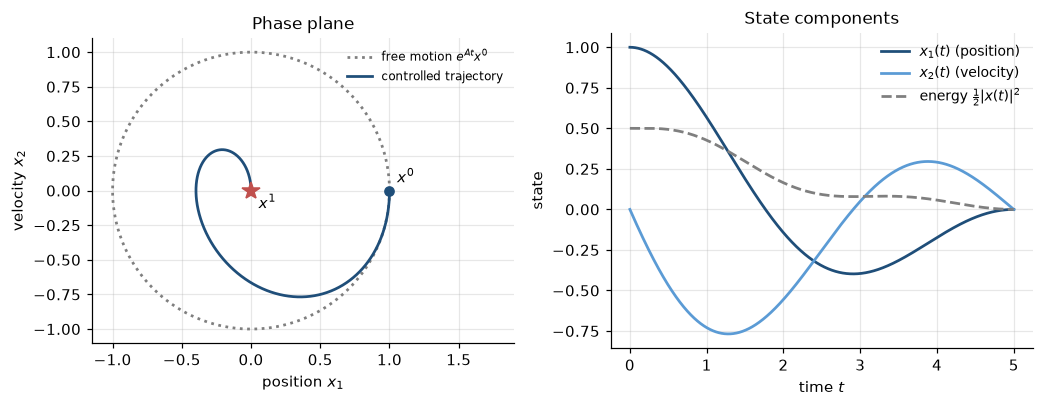

fraction of the horizon in which the energy increases: 12.3%


In [7]:
s = np.linspace(0, 2 * np.pi, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.8))

ax1.plot(np.cos(s), -np.sin(s), ":", color=COLORS["reference"], label="free motion $e^{At}x^0$")
ax1.plot(x_traj[:, 0], x_traj[:, 1], color=COLORS["state"], label="controlled trajectory")
ax1.plot(*x0, "o", color=COLORS["state"]); ax1.annotate("$x^0$", x0, xytext=(5, 5), textcoords="offset points")
ax1.plot(*x1, "*", ms=12, color=COLORS["control"]); ax1.annotate("$x^1$", x1, xytext=(5, -12), textcoords="offset points")
ax1.set_xlabel("position $x_1$"); ax1.set_ylabel("velocity $x_2$"); ax1.set_aspect("equal")
ax1.set_xlim(-1.15, 1.9); ax1.set_title("Phase plane"); ax1.legend(loc="upper right", fontsize=8)

energy = 0.5 * np.sum(x_traj**2, axis=1)
ax2.plot(t, x_traj[:, 0], color=COLORS["state"], label="$x_1(t)$ (position)")
ax2.plot(t, x_traj[:, 1], color=COLORS["state2"], label="$x_2(t)$ (velocity)")
ax2.plot(t, energy, "--", color=COLORS["reference"], label=r"energy $\frac{1}{2}|x(t)|^2$")
ax2.set_xlabel("time $t$"); ax2.set_ylabel("state"); ax2.set_title("State components")
ax2.legend()
plt.tight_layout(); plt.show()

energy_rising = np.mean(x_traj[:, 1] * u_hum[:, 0] > 0)      # E'(t) = x2(t) u(t)
print(f"fraction of the horizon in which the energy increases: {energy_rising:.1%}")

**Figure 2.** E1 with $x^0=(1,0)$, $x^1=0$, $T=5$. *Left:* phase plane. The dotted circle is the free motion $e^{At}x^0$, which conserves the energy. The solid curve is the trajectory under the HUM control $\hat{u}=B^*\hat{\varphi}$. *Right:* position, velocity and the energy $E(t)=\tfrac12|x(t)|^2$ against time.

*Interpretation (answer to the prediction).* The control does not fight the dynamics. It lets the oscillator swing and removes its energy, bringing the state to rest exactly at $t=T$. Since $E'(t)=x_2(t)\,u(t)$, energy is removed when the control opposes the velocity. This happens most of the time, but **not always**: during about 12% of the horizon the energy increases slightly. The minimal-$L^2$ control optimizes the *total* effort under an exact terminal constraint, not the energy loss at each instant. The autonomous linear feedback considered in [notebook 05](05_feedback_stabilization.ipynb) produces asymptotic decay and cannot reach the equilibrium in finite time from a nonzero initial state.

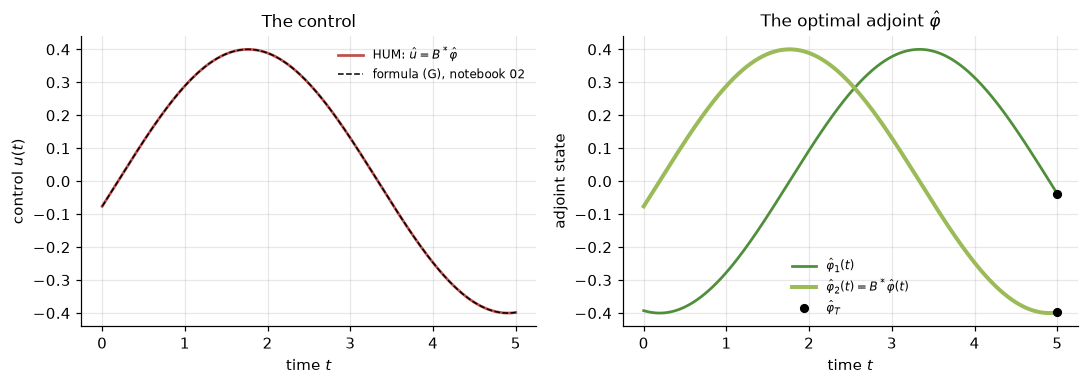

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax1.plot(t, u_hum[:, 0], color=COLORS["control"], label=r"HUM: $\hat{u}=B^*\hat{\varphi}$")
ax1.plot(t, u_02[:, 0], "--", color="black", linewidth=1.0, label="formula (G), notebook 02")
ax1.set_xlabel("time $t$"); ax1.set_ylabel("control $u(t)$"); ax1.set_title("The control")
ax1.legend(fontsize=8)

ax2.plot(t, phi_traj[:, 0], color=COLORS["adjoint"], label=r"$\hat{\varphi}_1(t)$")
ax2.plot(t, phi_traj[:, 1], color=COLORS["adjoint2"], lw=2.6, label=r"$\hat{\varphi}_2(t)=B^*\hat{\varphi}(t)$")
ax2.plot([T, T], phi_T_hum, "o", color="black", ms=5, label=r"$\hat{\varphi}_T$")
ax2.set_xlabel("time $t$"); ax2.set_ylabel("adjoint state"); ax2.set_title(r"The optimal adjoint $\hat{\varphi}$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 3.** *Left:* the HUM control $\hat{u}(t)=B^*e^{A^*(T-t)}\hat{\varphi}_T$ (solid), with $\hat{\varphi}_T$ obtained by minimizing $J$ through adjoint solves only. It is overlaid with the explicit control (G) of notebook 02 (dashed). *Right:* the optimal adjoint $\hat{\varphi}(t)$, computed backward from $\hat{\varphi}_T$ (black dots).

*Interpretation.* The two controls coincide (difference ≈ $10^{-10}$, see the diagnostics): formula (G) *is* the minimal-norm HUM control (§8). The control is the observed component $\hat{\varphi}_2$ of the optimal adjoint, the same curve in both panels, and it is determined by two numbers, $\hat{\varphi}_T\in\mathbb R^2$.

### 9.2 E2: losing controllability

Now consider the family
$$
A=\begin{pmatrix}0&1&0\\-1&0&0\\0&0&-1\end{pmatrix},\qquad B_\varepsilon=\begin{pmatrix}0\\1\\\varepsilon\end{pmatrix}.
$$
It couples the oscillator to a decaying mode $x_3'=-x_3+\varepsilon u$, which the actuator reaches only with strength $\varepsilon$. Its Kalman determinant is $-2\varepsilon$, so the pair is controllable if and only if $\varepsilon\ne0$.

We take $x^0=0$ and $x^1=e_3$, so $d=e_3$: we must excite the weakly actuated mode.

> **Predict.** As $\varepsilon\to0$, how do $\lambda_{\min}(\mathcal{G}_T)$, the condition number $\kappa(\mathcal{G}_T)$ and the minimal $L^2$ effort $\|\hat{u}\|_{L^2}$ behave? Guess the powers of $\varepsilon$.

In [9]:
epsilons = np.logspace(-3, 0, 13)
d = np.array([0.0, 0.0, 1.0])                    # x0 = 0, x1 = e3
lam_min, cond, u_norm = [], [], []
for eps in epsilons:
    A2, B2 = near_uncontrollable_system(eps)
    assert kalman_rank(A2, B2) == 3              # controllable for every eps > 0 ...
    G2 = gramian(A2, B2, T)
    ev = np.linalg.eigvalsh(G2)
    lam_min.append(ev[0])
    cond.append(ev[-1] / ev[0])
    u_norm.append(np.sqrt(d @ np.linalg.solve(G2, d)))   # ||u_hat||^2 = d^T G^{-1} d  (Section 8)
lam_min, cond, u_norm = map(np.array, (lam_min, cond, u_norm))

# The constant sigma_T of the predicted rates (derived in the DEEPER LOOK below):
# the squared L^2(0,T)-distance from r -> e^{-r} to span{sin r, cos r}.
r = time_grid(T, 4000)
w = np.vstack([np.sin(r), np.cos(r)])            # w(r) = e^{A_osc r} b_osc, the oscillator's response
g = np.array([simpson(np.exp(-r) * wi, x=r) for wi in w])
gamma = simpson(np.exp(-2 * r), x=r)
sigma_T = gamma - g @ np.linalg.solve(G, g)      # G is the E1 Gramian = int w w^T
print(f"sigma_T = {sigma_T:.6f}")

sigma_T = 0.331309


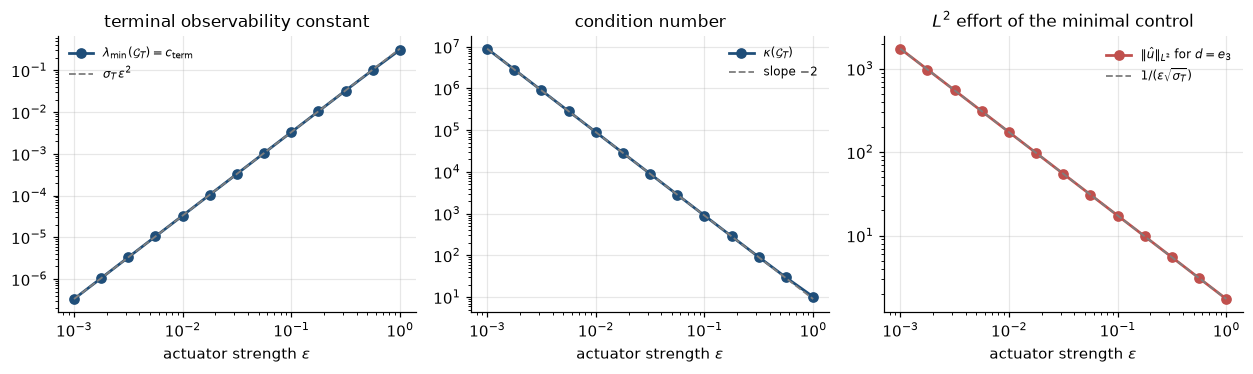

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5))
axes[0].loglog(epsilons, lam_min, "o-", color=COLORS["state"], label=r"$\lambda_{\min}(\mathcal{G}_T)=c_{\rm term}$")
slope_guide(axes[0], epsilons, sigma_T * epsilons[0]**2, 2, r"$\sigma_T\,\varepsilon^2$")
axes[0].set_title(r"terminal observability constant")

axes[1].loglog(epsilons, cond, "o-", color=COLORS["state"], label=r"$\kappa(\mathcal{G}_T)$")
slope_guide(axes[1], epsilons, cond[0], -2, r"slope $-2$")
axes[1].set_title("condition number")

axes[2].loglog(epsilons, u_norm, "o-", color=COLORS["control"], label=r"$\|\hat{u}\|_{L^2}$ for $d=e_3$")
slope_guide(axes[2], epsilons, 1 / (np.sqrt(sigma_T) * epsilons[0]), -1, r"$1/(\varepsilon\sqrt{\sigma_T})$")
axes[2].set_title(r"$L^2$ effort of the minimal control")
for ax in axes:
    ax.set_xlabel(r"actuator strength $\varepsilon$"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 4.** E2 with $T=5$, $x^0=0$, $x^1=e_3$, for $10^{-3}\le\varepsilon\le1$, on log–log axes. *Left:* the smallest eigenvalue of the Gramian, i.e. the best constant $c_{\rm term}$ in $\int_0^T|B^*\varphi|^2\ge c_{\rm term}|\varphi_T|^2$, the form relevant for reaching an arbitrary target such as $e_3$. *Middle:* the condition number $\kappa(\mathcal{G}_T)$. *Right:* the $L^2$ effort of the minimal (HUM) control. Dashed lines are the predicted rates.

*Interpretation (answer to the prediction).* The system is controllable for every $\varepsilon>0$; Kalman's rank test says *yes* throughout. Yet the terminal observability constant behaves like $\varepsilon^2$, the condition number like $\varepsilon^{-2}$, and the effort needed to reach $e_3$, a hard direction, like $\varepsilon^{-1}$. **Controllability is a yes/no property; observability constants measure *how* controllable a system is.**

The dashed lines rest on two facts proved in the DEEPER LOOK below: $\|\hat{u}\|_{L^2}=1/(\varepsilon\sqrt{\sigma_T})$ **exactly**, and $\lambda_{\min}(\mathcal{G}_T)/\varepsilon^2\to\sigma_T$ as $\varepsilon\to0$. Here $\sigma_T>0$ is the squared $L^2(0,T)$-distance from $e^{-r}$ to $\operatorname{span}\{\sin r,\cos r\}$.

#### Why these rates? (Schur complement)
`DEEPER LOOK`

Here $e^{Ar}B_\varepsilon=(w(r),\varepsilon e^{-r})$ with $w(r)=(\sin r,\cos r)$, the oscillator's response. Writing $D_\varepsilon=\operatorname{diag}(1,1,\varepsilon)$, the Gramian factorizes as

$$
\mathcal{G}_T(\varepsilon)=D_\varepsilon\,H\,D_\varepsilon,\qquad
H=\begin{pmatrix}G_{\rm osc}&g\\ g^*&\gamma\end{pmatrix},\quad
G_{\rm osc}=\int_0^Tww^*,\quad g=\int_0^Te^{-r}w(r)\,dr,\quad\gamma=\int_0^Te^{-2r}dr,
$$

where $H=\mathcal{G}_T(1)$ is positive definite and does not depend on $\varepsilon$.

*Exact effort.* By the block-inverse (Schur complement) formula, $(H^{-1})_{33}=1/\sigma_T$ with $\sigma_T=\gamma-g^*G_{\rm osc}^{-1}g$. Since $\mathcal{G}_T(\varepsilon)^{-1}=D_\varepsilon^{-1}H^{-1}D_\varepsilon^{-1}$, we get $e_3^*\mathcal{G}_T(\varepsilon)^{-1}e_3=1/(\varepsilon^2\sigma_T)$, that is, $\|\hat{u}\|_{L^2}=1/(\varepsilon\sqrt{\sigma_T})$ for **every** $\varepsilon>0$.

*Asymptotics of $\lambda_{\min}$.* The matrix $\varepsilon^2\mathcal{G}_T(\varepsilon)^{-1}=\varepsilon^2D_\varepsilon^{-1}H^{-1}D_\varepsilon^{-1}$ has entries $\varepsilon^2(H^{-1})_{ij}$ in the $2\times2$ block, $\varepsilon(H^{-1})_{i3}$ in the last row and column, and $(H^{-1})_{33}=1/\sigma_T$ in the corner. As $\varepsilon\to0$ it converges to $\operatorname{diag}(0,0,1/\sigma_T)$. Eigenvalues depend continuously on the matrix, so $\varepsilon^2\lambda_{\max}(\mathcal{G}_T(\varepsilon)^{-1})\to1/\sigma_T$, that is,
$$
\lambda_{\min}(\mathcal{G}_T(\varepsilon))/\varepsilon^2\;\longrightarrow\;\sigma_T\qquad(\varepsilon\to0,\ T\text{ fixed}).
$$
The other two eigenvalues of $\mathcal{G}_T(\varepsilon)$ converge to those of $G_{\rm osc}$, so $\kappa\sim\lambda_{\max}(G_{\rm osc})/(\sigma_T\varepsilon^2)$.

*The two observability constants.* For E2, $e^{AT}$ is not a rotation, so $c_0$ and $c_{\rm term}$ differ. The same argument applied to $e^{-AT}\mathcal{G}_Te^{-A^*T}$, whose third row and column are scaled by $\varepsilon e^{T}$ instead of $\varepsilon$, gives $c_0/\varepsilon^2\to\sigma_Te^{2T}$. Hence $c_0/c_{\rm term}\to e^{2T}$ **as $\varepsilon\to0$ with $T$ fixed**; this is an asymptotic statement, not an identity across the whole sweep. The weak mode decays by itself, so *driving it to zero* (null control, measured by $c_0$) is much cheaper than *exciting it* (our target $e_3$, measured by $c_{\rm term}$). The table below confirms these limits numerically; it illustrates the proof but does not replace it.

In [11]:
print("eps      lambda_min/eps^2   eps*||u_hat||   c_0/(eps^2 e^{2T})   c_0/c_term")
for eps in [1.0, 0.1, 0.01, 0.001]:
    A2, B2 = near_uncontrollable_system(eps)
    G2 = gramian(A2, B2, T)
    c_term = observability_constant(A2, B2, T, G2, form="terminal")
    c_0 = observability_constant(A2, B2, T, G2, form="initial")
    effort = np.sqrt(d @ np.linalg.solve(G2, d))
    print(f"{eps:6.3f}   {c_term / eps**2:14.6f}   {eps * effort:12.6f}   {c_0 / (eps**2 * np.exp(2 * T)):16.6f}"
          f"   {c_0 / c_term:10.1f}")
print(f"limits:  sigma_T = {sigma_T:.6f},  1/sqrt(sigma_T) = {1 / np.sqrt(sigma_T):.6f},  e^(2T) = {np.exp(2 * T):.1f}")

eps      lambda_min/eps^2   eps*||u_hat||   c_0/(eps^2 e^{2T})   c_0/c_term
 1.000         0.311325       1.737335           0.000085          6.0
 0.100         0.331119       1.737335           0.008425        560.4
 0.010         0.331307       1.737335           0.285362      18971.9
 0.001         0.331309       1.737335           0.330890      21998.6
limits:  sigma_T = 0.331309,  1/sqrt(sigma_T) = 1.737335,  e^(2T) = 22026.5


## 10. Optimization preview: conditioning slows gradient descent
`CORE` · **Forward connection to [notebook 06](06_variational_principles_gradient_flows.ipynb)**, where gradient descent is studied in its own right

The dual functional is a quadratic with Hessian $\mathcal{G}_T$. Suppose we minimize it by **gradient descent** (GD),
$$
\varphi_T^{(k+1)}=\varphi_T^{(k)}-\eta\,\nabla J\big(\varphi_T^{(k)}\big),\qquad\nabla J(\varphi_T)=\mathcal{G}_T\varphi_T-d .
$$

**The gradient has a meaning.** By the variation-of-constants formula, the state driven by $u=B^*\varphi$ from $x^0$ ends at $x_\varphi(T)=e^{AT}x^0+\mathcal{G}_T\varphi_T$. Hence

$$
\nabla J(\varphi_T)=x_\varphi(T)-x^1 :
$$

*the gradient of the dual functional is the terminal miss.* Each gradient step means: apply the control $B^*\varphi$, see by how much the target is missed, and correct the adjoint datum. It costs one adjoint solve and one state solve, and needs no Gramian (Exercise 5).

**Speed depends on the condition number, not on $\lambda_{\min}$ alone.** The error $e_k=\varphi_T^{(k)}-\hat{\varphi}_T$ obeys $e_{k+1}=(I-\eta\mathcal{G}_T)e_k$. With $\eta=1/\lambda_{\max}$, the component along $q_j$ is multiplied by $1-\lambda_j/\lambda_{\max}$ per step. The slowest mode, along $q_1$, contracts by $1-1/\kappa$, with $\kappa=\kappa(\mathcal{G}_T)$. For large $\kappa$ this gives the worst-case estimate
$$
k\;\approx\;\kappa\,\ln(1/\delta)
$$
for the number of steps needed to reduce the error by a factor $\delta$. The actual count depends on how much of the initial error lies along the slow modes. A small $\lambda_{\min}$ alone does *not* make GD slow: for $\mathcal{G}=\varepsilon^2I$, controls are expensive for small $\varepsilon$, yet $\kappa=1$ and GD with $\eta=1/\lambda_{\max}$ solves the problem in **one** step. For E2, $\kappa\sim\varepsilon^{-2}$, and GD becomes slow.

In [12]:
# The gradient of J is the terminal miss (E1, an arbitrary phi_T):
phi_check = np.array([0.3, -0.7])
x_end = simulate(A, B, hum_control(A, B, T, phi_check), x0, T, [0.0, T])[-1]
print("G phi - d     =", G @ phi_check - (x1 - expm(A * T) @ x0))
print("x_phi(T) - x1 =", x_end - x1)


def gradient_descent_hum(G, d, tol=1e-6, max_iter=500_000):
    # phi_{k+1} = phi_k - eta (G phi_k - d), eta = 1/lambda_max, from phi_0 = 0.
    # Stops at the first k with |phi_k - phi_hat| <= tol |phi_hat|; returns the relative errors.
    if not np.any(d):
        return np.array([0.0])                          # d = 0: the minimizer is phi = 0
    phi_star = np.linalg.solve(G, d)
    eta = 1.0 / np.linalg.eigvalsh(G)[-1]
    phi = np.zeros_like(d)
    errors = [1.0]
    while errors[-1] > tol:
        if len(errors) > max_iter:
            raise RuntimeError(f"gradient descent did not reach tol={tol} in {max_iter} steps")
        phi = phi - eta * (G @ phi - d)
        errors.append(np.linalg.norm(phi - phi_star) / np.linalg.norm(phi_star))
        if not np.isfinite(errors[-1]):
            raise FloatingPointError("gradient descent diverged")
    return np.array(errors)


print("G = eps^2 I (expensive controls, kappa = 1):", len(gradient_descent_hum(1e-4 * np.eye(3), d)) - 1, "step")

cases = {"E1": (G, x1 - expm(A * T) @ x0)}
for eps in [1.0, 0.3, 0.1, 0.03]:
    A2, B2 = near_uncontrollable_system(eps)
    cases[f"E2, eps={eps}"] = (gramian(A2, B2, T), d)

runs = {name: (np.linalg.cond(Gc), gradient_descent_hum(Gc, dc)) for name, (Gc, dc) in cases.items()}
for name, (kappa, errs) in runs.items():
    print(f"{name:14s} kappa = {kappa:10.1f}   steps to 1e-6: {len(errs) - 1:7d}"
          f"   worst-case estimate kappa*ln(1e6) = {kappa * np.log(1e6):9.0f}")

G phi - d     = [ 0.75263 -0.55794]
x_phi(T) - x1 = [ 0.75263 -0.55794]
G = eps^2 I (expensive controls, kappa = 1): 1 step


E1             kappa =        1.5   steps to 1e-6:      12   worst-case estimate kappa*ln(1e6) =        20
E2, eps=1.0    kappa =       10.2   steps to 1e-6:     134   worst-case estimate kappa*ln(1e6) =       140
E2, eps=0.3    kappa =      100.9   steps to 1e-6:    1388   worst-case estimate kappa*ln(1e6) =      1395
E2, eps=0.1    kappa =      900.3   steps to 1e-6:   12432   worst-case estimate kappa*ln(1e6) =     12438
E2, eps=0.03   kappa =     9993.2   steps to 1e-6:  138055   worst-case estimate kappa*ln(1e6) =    138062


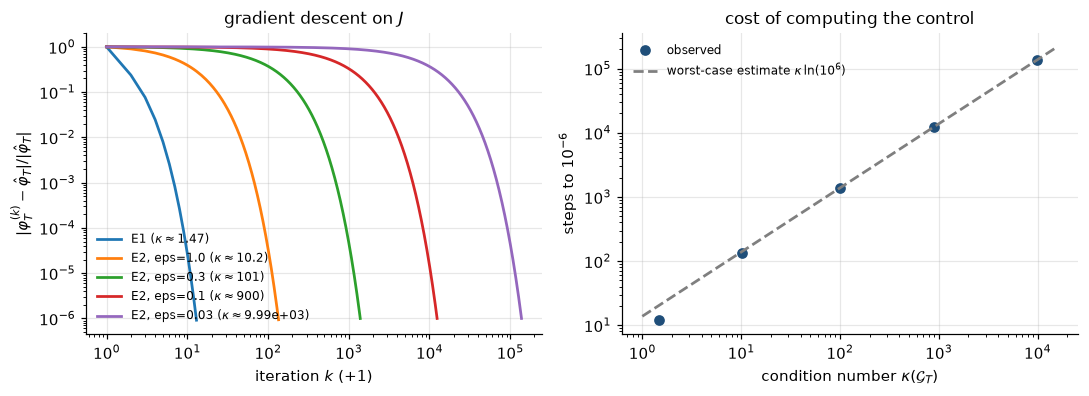

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.7))
for name, (kappa, errs) in runs.items():
    ax1.loglog(np.arange(1, len(errs) + 1), errs, label=rf"{name} ($\kappa\approx${kappa:.3g})")
ax1.set_xlabel("iteration $k$ (+1)"); ax1.set_ylabel(r"$|\varphi_T^{(k)}-\hat{\varphi}_T|/|\hat{\varphi}_T|$")
ax1.set_title("gradient descent on $J$"); ax1.legend(fontsize=8)

kappas = np.array([v[0] for v in runs.values()])
iters = np.array([len(v[1]) - 1 for v in runs.values()])
ax2.loglog(kappas, iters, "o", color=COLORS["state"], label="observed")
kk = np.logspace(0, np.log10(kappas.max()) + 0.2, 50)
ax2.loglog(kk, kk * np.log(1e6), "--", color=COLORS["reference"], label=r"worst-case estimate $\kappa\,\ln(10^6)$")
ax2.set_xlabel(r"condition number $\kappa(\mathcal{G}_T)$"); ax2.set_ylabel("steps to $10^{-6}$")
ax2.set_title("cost of computing the control"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 5.** Gradient descent with step $\eta=1/\lambda_{\max}(\mathcal{G}_T)$, starting from $\varphi_T^{(0)}=0$, on the HUM functional for E1 and for E2 with $\varepsilon\in\{1,0.3,0.1,0.03\}$, all with $T=5$. *Left:* relative error against the iteration number. *Right:* number of steps to reach relative error $10^{-6}$, against $\kappa(\mathcal{G}_T)$, with the worst-case estimate $\kappa\ln(10^6)$ (dashed).

*Interpretation.* For E1 ($\kappa\approx1.5$) about a dozen steps suffice, fewer than the worst-case estimate. For E2 the target $e_3$ lies almost along the slow mode, so the estimate is nearly attained, and each tenfold decrease of $\varepsilon$ multiplies $\kappa$, and the number of steps, by about one hundred: **conditioning of the dual problem → speed of iterative solvers.** Gradient descent is studied in [notebook 06](06_variational_principles_gradient_flows.ipynb); severe ill-conditioning for discretized PDEs returns in [notebook 07](07_adjoints_density_heat_control.ipynb).

## 11. What changes in infinite dimension?
`DEEPER LOOK`

Finite dimension entered the chain in two places (§5): compactness of the unit sphere, and the bounded inverse of $\varphi_T\mapsto\varphi(0)$. Here is what goes wrong without them.

**Injective does not imply bounded below.** On $\ell^2$, the diagonal operator $(Lv)_k=v_k/k$ is **injective**, the analogue of unique continuation, but **not bounded below**: $|e_k|=1$ while $|Le_k|=1/k\to0$. The proof of Proposition 3 breaks exactly where expected. The sequence $(e_k)$ lies on the unit sphere but has no convergent subsequence ($|e_j-e_k|=\sqrt2$), so the infimum $0$ of $|Lv|$ over the sphere is not attained.

**The heat equation: three different operators.** In this section $x\in(0,1)$ denotes the *spatial* variable. Consider the adjoint heat equation $-\varphi_t-\varphi_{xx}=0$ on $(0,1)$ with Dirichlet conditions and $\varphi(T)=\varphi_T$, observed on the *whole* interval, $\omega=(0,1)$. In the eigenbasis $e_k$ of $-\partial_{xx}$, with eigenvalues $\lambda_k=k^2\pi^2$, each mode evolves independently, and three operators must be kept apart.

- The **semigroup** $S_T:\varphi_T\mapsto\varphi(0)$, with $S_Te_k=e^{-\lambda_kT}e_k$. It is injective, but $s_{\min}$ of its $N$-mode truncation is $e^{-\lambda_NT}$. This is *not* an observability constant.
- The **observation operator** $\mathcal{O}_T:\varphi_T\mapsto\varphi|_{(0,T)\times\omega}$. Here
$$
\|\mathcal{O}_Te_k\|^2_{L^2((0,T)\times(0,1))}=\int_0^Te^{-2\lambda_k(T-t)}dt=\frac{1-e^{-2\lambda_kT}}{2\lambda_k}.
$$
- The **Gramian** $\mathcal{G}_T=\mathcal{O}_T^*\mathcal{O}_T$, which is diagonal with exactly these entries.

For the $N$-mode truncation, the entries above decrease with $\lambda$, so
$$
s_{\min}(\mathcal{O}_{T,N})=\sqrt{\frac{1-e^{-2\lambda_NT}}{2\lambda_N}}\sim\frac1{\sqrt2\,\pi N},
\qquad
c_{\rm term}(N)=\lambda_{\min}(\mathcal{G}_{T,N})=\frac{1-e^{-2\lambda_NT}}{2\lambda_N}\sim\frac1{2\pi^2N^2}.
$$
These decay **polynomially**, like $N^{-1}$ and $N^{-2}$. The exponential decay of $S_T$ does not transfer to the Gramian, and one should not infer exponential rates for heat-control Gramians from it.

In any case $c_{\rm term}(N)\to0$, so the **terminal** form of observability is impossible for the heat equation, even with observation on the whole domain.

The **initial** form (OBS) behaves differently. Mode by mode, the ratio $\|\mathcal{O}_Te_k\|^2/|S_Te_k|^2=(e^{2\lambda_kT}-1)/(2\lambda_k)$ increases with $k$, so
$$
\int_0^T\!\!\int_0^1|\varphi|^2\,dx\,dt\;\ge\;c_0\,|\varphi(0)|^2,\qquad c_0=\frac{e^{2\pi^2T}-1}{2\pi^2}>0,
$$
**uniformly in $N$**. The two forms of observability, equivalent in finite dimension, now give different answers, because $S_T$ has no bounded inverse.

This is why the slides state observability with $|\varphi(0)|^2$ on the right (pp. 96, 214). That form corresponds to null controllability. For observation on the whole domain it is elementary, as above. For a proper subset $\omega\subsetneq(0,1)$ it is a deep theorem (Fursikov–Imanuvilov, Lebeau–Robbiano; cited on p. 214), whose proof requires additional quantitative estimates, for example Carleman estimates or spectral methods. Compactness can no longer do the job ([notebook 07](07_adjoints_density_heat_control.ipynb)).

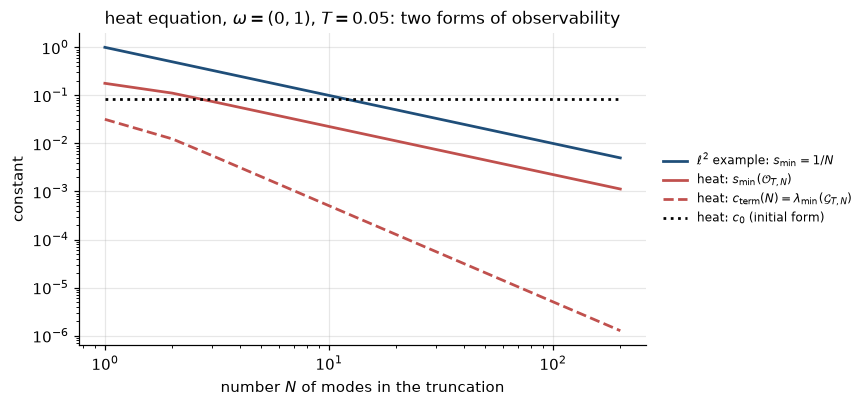

In [14]:
N = np.arange(1, 201)
T_heat = 0.05
lam_k = (np.pi * N) ** 2
g_term = -np.expm1(-2 * lam_k * T_heat) / (2 * lam_k)        # lambda_min(G_{T,N}) = c_term(N)
s_obs = np.sqrt(g_term)                                       # s_min(O_{T,N})
c0_heat = np.expm1(2 * np.pi**2 * T_heat) / (2 * np.pi**2)    # c_0, attained by the first mode

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.loglog(N, 1.0 / N, color=COLORS["state"], label=r"$\ell^2$ example: $s_{\min}=1/N$")
ax.loglog(N, s_obs, color=COLORS["control"], label=r"heat: $s_{\min}(\mathcal{O}_{T,N})$")
ax.loglog(N, g_term, "--", color=COLORS["control"], label=r"heat: $c_{\rm term}(N)=\lambda_{\min}(\mathcal{G}_{T,N})$")
ax.loglog(N, np.full_like(N, c0_heat, dtype=float), ":", color="black", label=r"heat: $c_0$ (initial form)")
ax.set_xlabel("number $N$ of modes in the truncation")
ax.set_ylabel("constant")
ax.set_title(r"heat equation, $\omega=(0,1)$, $T=0.05$: two forms of observability")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8); plt.tight_layout(); plt.show()

**Figure 6.** For $N$-mode truncations, on log–log axes: the smallest singular value $1/N$ of $\operatorname{diag}(1/k)$; for the heat equation on $(0,1)$ observed on all of $(0,1)$ with $T=0.05$, the smallest singular value of the observation operator $\mathcal{O}_{T,N}$, the terminal constant $c_{\rm term}(N)=\lambda_{\min}(\mathcal{G}_{T,N})$, and the initial constant $c_0$. All values are computed from the closed-form expressions in the text. The semigroup $S_T$ is not plotted: its singular values $e^{-\lambda_kT}$ are not observability constants.

*Interpretation.* Every truncation is injective, and the terminal constant is positive for each $N$. But it tends to zero, like $N^{-2}$, so no single constant works in infinite dimension. The initial constant $c_0$ stays bounded away from zero. In finite dimension the two forms of observability were equivalent; for the heat equation one holds and the other fails.

## 12. Control ↔ ML connection
`CORE` · *Preview only*

**The adjoint propagates sensitivity information backwards.** In §1, $B^*\varphi(s)$ was the derivative of $\langle x(T),\varphi_T\rangle$ with respect to the control at time $s$, obtained by *one* backward solve. The same structural idea will reappear as **backpropagation**. A residual network is a discretized controlled ODE whose parameters play the role of $u$, and the gradient of the loss with respect to all parameters comes from one backward adjoint sweep.

The adjoint method is developed in [notebook 07](07_adjoints_density_heat_control.ipynb), and backpropagation is derived as a discrete adjoint in [notebook 13](13_resnets_neural_odes.ipynb). The slides state that backpropagation is reverse-mode differentiation (p. 53); the link with the adjoint system is drawn in these notebooks.

## 13. Common misconceptions
`CORE`

**"A controllable system is a stable one."** No. E1 is controllable but conserves its energy. The third mode of E2 at $\varepsilon=0$, $x_3'=-x_3$, is stable but cannot be influenced at all.

**"Unique continuation and observability are the same thing."** Only in finite dimension, through compactness and a bounded inverse (§5). For PDEs, observability is the hard theorem (§11).

**"The adjoint is a clever trick."** It appears automatically when one asks how a measurement of the final state depends on the control (§1), and it is defined so that the free dynamics cancels in (D).

**"Minimizing $J$ is just one more numerical method."** It is the constructive dual formulation of controllability: coercivity comes from observability, the minimizer gives the least-effort control, and $-\min J$ is its quadratic cost.

**"A small observability constant makes every target expensive and gradient descent slow."** It makes the *hard directions* expensive (§8). The speed of GD depends on $\kappa$, not on $\lambda_{\min}$ alone (§10).

**"The HUM control is *the* control."** It is the one of minimal $L^2$ norm among infinitely many. Other functionals select other structures ([notebook 04](04_structured_controls_bangbang_switching.ipynb)).

## 14. What you should remember
`CORE`

1. Testing $x(T)$ against every direction $\varphi_T$ turns reachability into scalar identities, and the adjoint system $-\varphi'=A^*\varphi$, $\varphi(T)=\varphi_T$, appears by itself.
2. Duality identity: $\langle x(T),\varphi_T\rangle-\langle x^0,\varphi(0)\rangle=\int_0^T\langle u,B^*\varphi\rangle\,dt$.
3. The HUM functional $J(\varphi_T)=\tfrac12\int_0^T|B^*\varphi|^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle$ is reverse-engineered so that its Euler–Lagrange equation is the control condition.
4. Unique continuation ⇒ observability ⇒ coercivity ⇒ existence; strict convexity ⇒ uniqueness. Finite dimension enters through compactness and a bounded inverse.
5. The control is the observation of the optimal adjoint, $\hat{u}=B^*\hat{\varphi}$. It has minimal $L^2$ effort, and $\min\tfrac12\|u\|^2=-\min J$.
6. $\nabla^2J=\mathcal{G}_T$: the explicit Gramian control *is* the HUM control.
7. $\|\hat{u}\|^2=\sum_j|\langle d,q_j\rangle|^2/\lambda_j$: small eigenvalues make the hard directions expensive, with worst case $\lambda_{\min}^{-1/2}$. The speed of gradient descent is governed by $\kappa(\mathcal{G}_T)$.
8. To control is to observe the adjoint. This structure returns for PDEs (07), long-time control (08) and backpropagation (13).

## 15. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (invisible directions).** Take E2 with $\varepsilon=0$.
(a) Find all terminal data $\varphi_T$ for which $B^*\varphi(t)=0$ on $(0,T)$.
(b) Use the duality identity (D) to show that, for such $\varphi_T$, the number $\langle x(T),\varphi_T\rangle$ is the same for every control.
(c) Starting from $x^0=0$, which targets are reachable? Answer in words, then compare with the Kalman rank.

**Exercise 2 ★★ (why go to the dual?).** The minimal-norm control solves the *primal* problem: minimize $\tfrac12\|u\|_{L^2}^2$ subject to $x(T)=x^1$, over an infinite-dimensional space with $n$ constraints. HUM instead minimizes $J$ over $\varphi_T\in\mathbb R^n$, without constraints.
(a) Introduce a **Lagrange multiplier** $\lambda\in\mathbb R^n$ for the constraint and form the Lagrangian $\tfrac12\|u\|^2-\langle\lambda,x(T)-x^1\rangle$. *Hint:* write $x(T)$ by variation of constants, differentiate with respect to $u$ in a direction $\delta u$, and set the result to zero for all $\delta u$. Which object of this notebook is $\lambda$?
(b) Substitute the optimal $u$ back into the Lagrangian. What function of $\lambda$ do you obtain?
(c) In a few sentences: what is gained by passing to the dual problem? In what sense does this illustrate "PRIMAL = DUAL" (p. 20)?

**Exercise 3 ★★ (the Gramian of the oscillator).** For E1:
(a) show that $\mathcal{G}_T=\dfrac T2I+\dfrac14\begin{pmatrix}-\sin2T&1-\cos2T\\1-\cos2T&\sin2T\end{pmatrix}$;
(b) deduce $\lambda_\pm(\mathcal{G}_T)=\tfrac12(T\pm|\sin T|)$;
(c) deduce that the worst-case minimal effort is $\max_{|d|=1}\|\hat{u}\|_{L^2}=\sqrt{2/(T-|\sin T|)}$;
(d) find its behaviour as $T\to0$ and as $T\to\infty$, and interpret both regimes.

**Exercise 4 ★★ (what if controllability fails?).** Suppose $\operatorname{rank}\mathcal{K}(A,B)<n$, and let $d=x^1-e^{AT}x^0$.
(a) Show that $J$ is convex but not coercive, and that its quadratic part vanishes exactly on $\ker\mathcal{G}_T=(\operatorname{Range}\mathcal{K})^\perp$.
(b) Show that $J$ is bounded below if and only if $d\in\operatorname{Range}\mathcal{G}_T$, that is, if and only if $x^1\in\mathcal{R}(T,x^0)$.
(c) Show that in that case $J$ has infinitely many minimizers, and that they all produce the same control $B^*\hat{\varphi}$.

**Exercise 5 ★★★ (gradient descent by shooting).** Implement $\nabla J(\varphi_T)=x_\varphi(T)-x^1$ **without assembling the Gramian**, using only simulations of the state equation driven by $u=B^*\varphi$.
In this experiment you may use the Gramian of §9.1 for two auxiliary purposes only: to choose the step $\eta=1/\lambda_{\max}(\mathcal{G}_T)$, and as a reference solution $\hat{\varphi}_T$ for measuring errors.
Run 20 gradient-descent steps on E1 from $\varphi_T=0$ and plot $|\varphi_T^{(k)}-\hat{\varphi}_T|$ against $k$, together with the bound $(1-\lambda_{\min}/\lambda_{\max})^k|\hat{\varphi}_T|$.
Then **separate the two sources of error**: estimate the error floor caused by the ODE solver from $|\nabla J_{\rm shoot}(\hat{\varphi}_T)|$, the shooting gradient at the exact minimizer, and compare it with the optimization error. How many state simulations did you need? *Hint:* `simulate` and `hum_control`.

In [15]:
# TODO: student exercise (Exercise 5)
# 1. Write grad_J_shooting(phi_T): simulate x' = Ax + Bu with u = B^T phi(t), x(0) = x0,
#    and return x(T) - x1.  Do not use the Gramian here.
# 2. Run 20 gradient-descent steps from phi_T = 0 with eta = 1 / lambda_max(G).
# 3. Plot the error against k with the predicted bound, and estimate the ODE error floor.

def grad_J_shooting(phi_T):
    ...  # your code here
    return None

**Exercise 6 ★★★ (conjugate gradients).** For E2 with $d=e_3$, implement the conjugate-gradient (CG) method for $\mathcal{G}_T\varphi_T=d$. Stop when the **true relative residual** $\|\mathcal{G}_T\varphi-d\|/\|d\|$ is below $10^{-10}$.
For $\varepsilon\in\{1,0.1,0.01\}$, report the number of iterations, the true relative residual, and the relative error with respect to a reference solution from `np.linalg.solve`.
Run gradient descent with the **same** stopping criterion where this is affordable, and say explicitly where you only use the estimate $\kappa\ln(10^{10})$.
Explain (a) why CG terminates in at most $n=3$ steps *in exact arithmetic*, and (b) why that guarantee does not provide a mesh-independent iteration bound for discretized PDEs ([notebook 07](07_adjoints_density_heat_control.ipynb)).

In [16]:
# TODO: student exercise (Exercise 6)
# Implement conjugate_gradient(G, d, tol) returning (solution, number_of_iterations),
# stopping on the true relative residual ||G phi - d|| / ||d||, then run it on the
# E2 Gramians for eps in [1, 0.1, 0.01].

def conjugate_gradient(G, d, tol=1e-10, max_iter=100):
    ...  # your code here
    return None, 0

## Where are we going?
`CORE`

The architecture built here, *adjoint system → observability → coercive dual functional → control*, is the template for much of the course.

- **[Notebook 04](04_structured_controls_bangbang_switching.ipynb)** keeps the same adjoint but **changes the dual functional**. Replacing $\tfrac12\int|B^*\varphi|^2$ by $\tfrac12\big(\int|B^*\varphi|\big)^2$ gives **bang-bang** controls of minimal amplitude, and a $\max$ over two actuators gives **switching** controls.
- **[Notebook 05](05_feedback_stabilization.ipynb)** uses **observability for stabilization**: the feedback $u=-B^*x$ makes a conservative system decay, and the observability inequality is exactly what gives the decay rate.
- **[Notebook 07](07_adjoints_density_heat_control.ipynb)** repeats the **same architecture for the heat equation**. There, observability is the hard part (§11), and discretized dual problems are severely ill-conditioned (§10).
- **[Notebook 13](13_resnets_neural_odes.ipynb)** **closes the adjoint thread**: backpropagation in residual networks is the discrete adjoint system of a controlled ODE.

The coercive-minimization principle also returns in [notebook 06](06_variational_principles_gradient_flows.ipynb), which treats the existence of minimizers and gradient methods in general.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`. The machine-readable version, which separates slide content, pedagogical additions and corrections of this notebook, is in `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| Where are we? (recap) | 87–88, 91, 99 | System, variation of constants, controllability, reachable set, Kalman theorem |
| §1–2 Adjoint system | 92 | Adjoint system $-\varphi'=A^*\varphi$, $\varphi(T)=\varphi_T$ |
| §3 Duality identity, Lemma 1 | 92–93 | Characterization of null controllability and its proof |
| §3 General target | 111 | Functional with $-x^1\cdot\varphi^0+x^0\cdot\varphi(0)$ (switching context) |
| §4 Functional, Lemma 2 | 94–95 | Functional $J(\varphi_T)$; the minimizer gives the control $B^*\hat{\varphi}$ |
| §5 Observability | 96–97 | Observability inequality; equivalence with unique continuation (finite dimension, compactness) |
| §5a Unique continuation ⟺ Kalman | 100 | Derivatives at $t=T$ |
| §6 Summary | 98, 20, 132 | "Unique continuation → observability → controllability"; "PRIMAL = DUAL, CONTROL = COMMUNICATION"; Wiener's cybernetics |
| §7 Minimal $L^2$ norm | 105–106 | Proposition and proof (Cauchy–Schwarz version) |
| §11 Infinite dimension (outlook) | 97, 214 | Failure of the equivalence for PDEs; heat observability with $\varphi(0)$ |
| §12 Backpropagation (outlook) | 53 | Backpropagation = reverse-mode automatic differentiation |

**Added or corrected in this notebook:** listed row by row in `source_map.csv` (content types `pedagogical-addition` and `notebook-correction`).